In [1]:
import numpy as np
import sys
import os

# Add the library path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

from ex_fuzzy_reg import fuzzy_sets as fs
from ex_fuzzy_reg import fuzzy_variable as fv
from ex_fuzzy_reg import rules_reg as r

### Mamdani Inference:

In [2]:
bad  = fs.TriangularFS('Bad', [0, 0, 5], [0, 10])
medium = fs.TrapezoidalFS('Medium', [2.5, 4, 6, 7], [0, 10])
good = fs.TriangularFS('Good', [6, 10, 10], [0, 10])
service = fv.FuzzyVariable('Service', [bad, medium, good])

In [3]:
poor  = fs.TriangularFS('Poor', [0, 0, 4], [0, 10])
normal = fs.TrapezoidalFS('Normal', [2.5, 4, 5, 7], [0, 10])
good_food = fs.TriangularFS('Good', [6.5, 10, 10], [0, 10])
food = fv.FuzzyVariable('Food', [poor, normal, good_food])

In [4]:
low = fs.TriangularFS('Low', [0, 0, 11], [0, 20])
medium_tip = fs.TriangularFS('Medium', [10, 12, 14], [0, 20])
high = fs.TriangularFS('High', [13.5, 20, 20], [0, 20])
tip = fv.FuzzyVariable('Tip', [low, medium_tip, high])

In [5]:
R1 = r.RuleSimple([0, 0], 0)  # Bad, Poor -> Low
R2 = r.RuleSimple([0, 1], 0)  # Bad, Normal -> Low
R3 = r.RuleSimple([1, 0], 1)  # Medium, Poor -> Medium
R4 = r.RuleSimple([2, 2], 2)  # Good, Good -> High
R5 = r.RuleSimple([1, 1], 1)  # Medium, Medium -> Medium

RB = r.RuleBaseRegT1(
    antecedents=[service, food],
    rules=[R1, R2, R3, R4, R5],
    consequent=tip
)

RB.print_rules()
print("\nRuleBase Matrix:")
print(RB.get_rulebase_matrix())

IF Service IS Bad AND Food IS Poor THEN consequent vl is 0
IF Service IS Bad AND Food IS Normal THEN consequent vl is 0
IF Service IS Medium AND Food IS Poor THEN consequent vl is 1
IF Service IS Good AND Food IS Good THEN consequent vl is 2
IF Service IS Medium AND Food IS Normal THEN consequent vl is 1


RuleBase Matrix:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [2. 2.]
 [1. 1.]]


In [9]:
x = np.array([
    [1, 3],
    [4, 2],
    [9, 10],
    [5, 6],
    [10, 10],
    [7, 7]
])

y = RB.inference(x)
for i, (xi, yi) in enumerate(zip(x, y)):
    print(f"[{i}] Service: {xi[0]}, Food: {xi[1]} -> Tip: {yi}")

AttributeError: module 'ex_fuzzy_reg.fuzzy_sets' has no attribute 'union'

### TSK Inference:

This demo is based from Tomohiro Takagi and Michio Sugeno paper from 1985: "Fuzzy Identification of Systems and Its
Applications to Modeling and Control".


* #### Fuzzy variables and their linguistic variables:

The demo consist of 2 fuzzy variables: $x_1$ and $x_2$, with the following triangular linguistic variables:

* $x_1$ small: [0, 0, 16]
* $x_1$ big: [10, 20, 20]

* $x_2$ small: [0, 0, 8]
* $x_2$ big: [2, 2, 10]

The variables can be visualized in the plots below.

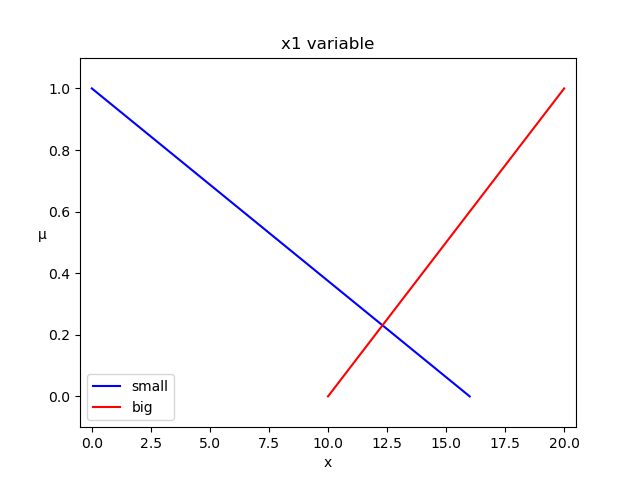

In [ ]:
# x1 linguistic variables creation
x1_small = fs.TriangularFS('x1 small', [0, 0, 16], [0, 20])
x1_big = fs.TriangularFS('x1 big', [10, 20, 20], [0, 20])

# x1 fuzzy variable creation
X1 = fv.FuzzyVariable('x1', [x1_small, x1_big])

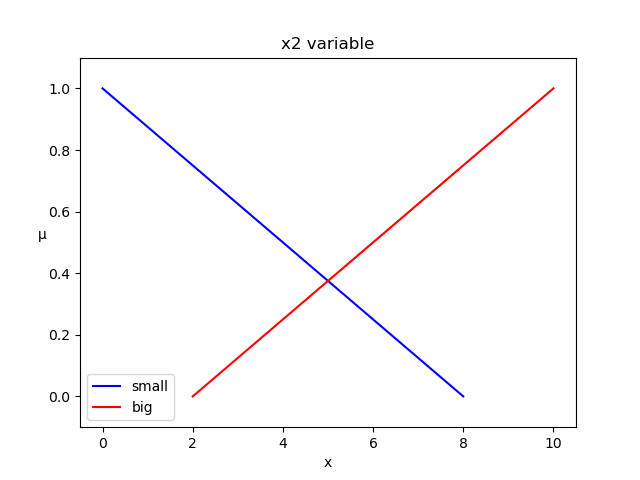

In [ ]:
# x2 linguistic variables creation
x2_small = fs.TriangularFS('x2 small', [0, 0, 8], [0, 10])
x2_big = fs.TriangularFS('x2 big', [2, 10, 10], [0, 10])

# x2 fuzzy variable creation
X2 = fv.FuzzyVariable('x2', [x2_small, x2_big])

* #### Rule Base creation:

In contrast to a Mamdani system, a TSK system defines the consequents as a function based on the antecedent parameters, in this case $x_1$ and $x_2$.

The rule base used will have 3 rules:
- R1: IF $x_1$ IS small AND $x_2$ IS small THEN $y = x_1 + x_2$
- R2: IF $x_1$ IS big THEN $y = 2 x_1$
- R3: IF $x_2$ IS big THEN $y = 3 x_2$

In [ ]:
# Consequent creation for each rule. The parameters are the coefficient of each antecedent variable 
R1_consq = r.ConsequentTSK([1, 1]) # y = 1*x1 + 1*x2
R2_consq = r.ConsequentTSK([2, 0]) # y = 2*x1 + 0*x2
R3_consq = r.ConsequentTSK([0, 3]) # y = 0*x1 + 3*x2

# Rule creation
R1 = r.RuleSimpleTSK([0, 0], R1_consq)
R2 = r.RuleSimpleTSK([1, -1], R2_consq)
R3 = r.RuleSimpleTSK([-1, 1], R3_consq)

# Rule base creation
RB = r.RuleBaseRegTSK([X1, X2], [R1, R2, R3])

NameError: name 'r' is not defined

In [25]:
x = np.array([[12, 5]])

print(round(RB.inference(x)[0], 1))

17.8
